In [14]:
import os
import pickle
import numpy as np
import arviz as az
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import ustreasurycurve as ustcurve

from Library.Utility import UST_TENOR_MAP
from Library.OptionPricerBSM1973 import BlackScholesMertonPut
from Library.SkewCalibrationHeston1993 import HestonSkewCalibration, feller_condition
from Library.SkewCalibrationKimYi2025 import KimYiSkewCalibrationSystematic, KimYiSkewCalibrationIdiosyncratic
from scipy.optimize import minimize
from nelson_siegel_svensson.calibrate import calibrate_nss_ols

az.style.use("arviz-darkgrid")

DATA_PATH_INPUT_VOLS_STR = r"/Users/josephyi/Library/Mobile Documents/com~apple~CloudDocs/Data/Implied Volatility"
DATA_PATH_CALIB_RSLT_STR = os.path.join(os.path.join(os.getcwd(), os.pardir), r"Study/Estimated Parameters QLSQ")
UND_TICKERS_DICT = {'systematic': '^SPX', 'idiosyncratic': ['COIN']}
DIVIDEND_YIELDS = {'^SPX': 1.25}
EXPIRY_MAP = {0: 11, 1: 10, 2: 9, 3: 8, 4: 7}

In [12]:
calib_rslts_kimyi2025_file_name = "kimyi2025_vol_calibration.pkl"
calib_rslts_heston1993_file_name = "heston1993_vol_calibration.pkl"

try:
    # Open the file in binary read mode ('rb')
    file_path = os.path.join(DATA_PATH_CALIB_RSLT_STR, calib_rslts_kimyi2025_file_name)
    with open(file_path, 'rb') as file:
        # Load the pickled data
        calib_rslts_kimyi2025 = pickle.load(file)

    # Now, 'loaded_data' contains the Python object that was saved
    print("Data successfully loaded from pickle file:")
    print(file_path)

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred while loading the pickle file: {e}")

try:
    # Open the file in binary read mode ('rb')
    file_path = os.path.join(DATA_PATH_CALIB_RSLT_STR, calib_rslts_heston1993_file_name)
    with open(file_path, 'rb') as file:
        # Load the pickled data
        calib_rslts_heston1993 = pickle.load(file)

    # Now, 'loaded_data' contains the Python object that was saved
    print("Data successfully loaded from pickle file:")
    print(file_path)

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred while loading the pickle file: {e}")

Data successfully loaded from pickle file:
/Users/josephyi/PycharmProjects/mkt-depth-n-resiliency/Scripts/../Study/Estimated Parameters QLSQ/kimyi2025_vol_calibration.pkl
Data successfully loaded from pickle file:
/Users/josephyi/PycharmProjects/mkt-depth-n-resiliency/Scripts/../Study/Estimated Parameters QLSQ/heston1993_vol_calibration.pkl


In [2]:
valuation_date_array = pd.bdate_range('2025-03-18', '2025-04-17')
# https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics?data=yield%27
rates_data_df = ustcurve.nominalRates(valuation_date_array[0].strftime("%Y-%m-%d"), valuation_date_array[-1].strftime("%Y-%m-%d")).set_index('date')
rates_data_df = pd.DataFrame(index=pd.date_range(rates_data_df.index.min(), rates_data_df.index.max())).join(rates_data_df).ffill(axis=1).bfill(axis=1).ffill().bfill()
rates_tenors = np.array([UST_TENOR_MAP[x] for x in rates_data_df.columns])
rates_data_df.head()

,1m,1.5m,2m,3m,4m,6m,1y,2y,3y,5y,7y,10y,20y,30y
2025-03-18,4.37,4.35,4.33,4.34,4.29,4.29,4.13,4.04,4.01,4.07,4.18,4.29,4.61,4.58
2025-03-19,4.37,4.34,4.32,4.33,4.30,4.29,4.10,3.99,3.95,4.03,4.14,4.25,4.58,4.56
2025-03-20,4.36,4.34,4.34,4.33,4.29,4.27,4.06,3.95,3.93,4.01,4.12,4.24,4.57,4.55
2025-03-21,4.36,4.33,4.33,4.33,4.29,4.26,4.04,3.94,3.92,4.00,4.12,4.25,4.60,4.59
2025-03-22,4.36,4.33,4.33,4.33,4.29,4.26,4.04,3.94,3.92,4.00,4.12,4.25,4.60,4.59


In [3]:
PATH_STR = os.path.join(DATA_PATH_INPUT_VOLS_STR, UND_TICKERS_DICT['systematic'].split("^")[-1])

mkt_vol_df1 = pd.concat([pd.read_csv(os.path.join(PATH_STR, file)) for file in sorted(os.listdir(PATH_STR))])

mkt_vol_df2 = []
for underlying_name in UND_TICKERS_DICT['idiosyncratic']:

    PATH_STR = os.path.join(DATA_PATH_INPUT_VOLS_STR, underlying_name)

    tmp_df = pd.concat([pd.read_csv(os.path.join(PATH_STR, file)) for file in sorted(os.listdir(PATH_STR))])

    mkt_vol_df2.append(tmp_df)

mkt_vol_df2 = pd.concat(mkt_vol_df2)
mkt_vol_df = pd.concat([mkt_vol_df1, mkt_vol_df2])

mkt_vol_df.quote_date = pd.to_datetime(mkt_vol_df.quote_date)
mkt_vol_df.expiration = pd.to_datetime(mkt_vol_df.expiration)

mkt_vol_df['iEXPIRY'] = (mkt_vol_df.expiration - mkt_vol_df.quote_date).dt.days
mkt_vol_df['dEXPIRY'] = mkt_vol_df.iEXPIRY / 365

mkt_vol_df['dUND_PRICE'] = mkt_vol_df.active_underlying_price_1545
mkt_vol_df['dUND_STRIKE'] = mkt_vol_df.strike
mkt_vol_df['dMONEYNESS'] = mkt_vol_df.dUND_STRIKE / mkt_vol_df.dUND_PRICE * 100.
mkt_vol_df['dMKT_IMP_VOL'] = mkt_vol_df.implied_volatility_1545

mask = mkt_vol_df.option_type=='C'
mkt_vol_df['bIS_CALL_OPTION'] = False
mkt_vol_df.loc[mask, 'bIS_CALL_OPTION'] = True

mask  = (mkt_vol_df.trade_volume > 0) & (mkt_vol_df.iEXPIRY > 5) & (mkt_vol_df.dMKT_IMP_VOL > 0)
mkt_vol_df = mkt_vol_df.loc[mask]

mask = (mkt_vol_df.option_type=='P') & (mkt_vol_df.dMONEYNESS <= 100.) & (mkt_vol_df.dMONEYNESS >= 50.)
mkt_vol_df1 = mkt_vol_df.loc[mask]
mask = (mkt_vol_df.option_type=='C') & (mkt_vol_df.dMONEYNESS >= 100.) & (mkt_vol_df.dMONEYNESS <= 150.)
mkt_vol_df2 = mkt_vol_df.loc[mask]

mkt_vol_df = pd.concat([mkt_vol_df1, mkt_vol_df2])

for t in mkt_vol_df.quote_date.unique():
    rate_fitter, _ = calibrate_nss_ols(rates_tenors, rates_data_df.xs(t).to_numpy() / 100)
    mask = (mkt_vol_df.quote_date==t)
    mkt_vol_df.loc[mask, 'dRISK_FREE_RATE'] = mkt_vol_df.loc[mask, 'dEXPIRY'].apply(rate_fitter)

mkt_vol_df['dDIVIDEND_YIELD'] = DIVIDEND_YIELDS[mkt_vol_df.underlying_symbol.iloc[0]] / 100.

vegas = []
for tup in mkt_vol_df.itertuples():
    vega = BlackScholesMertonPut(
        und_price=np.array(tup.dUND_PRICE),
        und_strike=np.array(tup.dUND_STRIKE),
        risk_free_rate=np.array(tup.dRISK_FREE_RATE),
        dividend_yield=np.array(tup.dDIVIDEND_YIELD),
        time_to_expiry=np.array(tup.dEXPIRY)
    ).vega(np.array(tup.dMKT_IMP_VOL)) / 100.
    vegas.append(vega[0, 0])

mkt_vol_df['dVEGA'] = vegas

In [67]:
valuation_date = '20250409'
systematic_name = UND_TICKERS_DICT['systematic']
T = EXPIRY_MAP[pd.to_datetime(valuation_date).weekday()]
if (pd.to_datetime(valuation_date) >= pd.to_datetime('20250407')) and (pd.to_datetime(valuation_date) < pd.to_datetime('20250414')):
    T = T - 1
mask  = (mkt_vol_df.underlying_symbol==systematic_name)
mask &= (mkt_vol_df.quote_date==valuation_date) & (mkt_vol_df.iEXPIRY==T) & (mkt_vol_df.dMONEYNESS >= 50.) & (mkt_vol_df.dMONEYNESS <= 150.)
tmp_df = mkt_vol_df.loc[mask].sort_values('dMONEYNESS')
tmp_df.dMKT_IMP_VOL *= 100.
expiry_date = tmp_df.expiration.iloc[0]

vol_fitter = KimYiSkewCalibrationSystematic(
    mkt_imp_vol=tmp_df.dMKT_IMP_VOL.to_numpy() / 100.,
    und_price=tmp_df.dUND_PRICE.to_numpy(),
    und_strike=tmp_df.dUND_STRIKE.to_numpy(),
    risk_free_rate=tmp_df.dRISK_FREE_RATE.to_numpy(),
    dividend_yield=tmp_df.dDIVIDEND_YIELD.to_numpy(),
    time_to_expiry=tmp_df.dEXPIRY.to_numpy(),
    is_call_option=tmp_df.bIS_CALL_OPTION.to_numpy(),
    option_weights=tmp_df.dVEGA.to_numpy() / tmp_df.dVEGA.sum()
)

tmp_df['dMOD_IMP_VOL_KY'] = vol_fitter.model_vol(x=calib_rslts_kimyi2025[f"{systematic_name}-{valuation_date}"].x) * 100.

vol_fitter = HestonSkewCalibration(
    mkt_imp_vol=tmp_df.dMKT_IMP_VOL.to_numpy() / 100.,
    und_price=tmp_df.dUND_PRICE.to_numpy(),
    und_strike=tmp_df.dUND_STRIKE.to_numpy(),
    risk_free_rate=tmp_df.dRISK_FREE_RATE.to_numpy(),
    dividend_yield=tmp_df.dDIVIDEND_YIELD.to_numpy(),
    time_to_expiry=tmp_df.dEXPIRY.to_numpy(),
    is_call_option=tmp_df.bIS_CALL_OPTION.to_numpy(),
    option_weights=tmp_df.dVEGA.to_numpy() / tmp_df.dVEGA.sum()
)

tmp_df['dMOD_IMP_VOL_H'] = vol_fitter.model_vol(x=calib_rslts_heston1993[f"{systematic_name}-{valuation_date}"].x) * 100.

/Users/josephyi/anaconda3/envs/liquidity/lib/python3.10/site-packages/scipy/integrate/_quadpack_py.py:611: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagse(func,a,b,args,full_output,epsabs,epsrel,limit)
/Users/josephyi/PycharmProjects/mkt-depth-n-resiliency/Library/SkewCalibrationHeston1993.py:168: RuntimeWarning: some derivatives were zero
  mod_iv_call = newton(


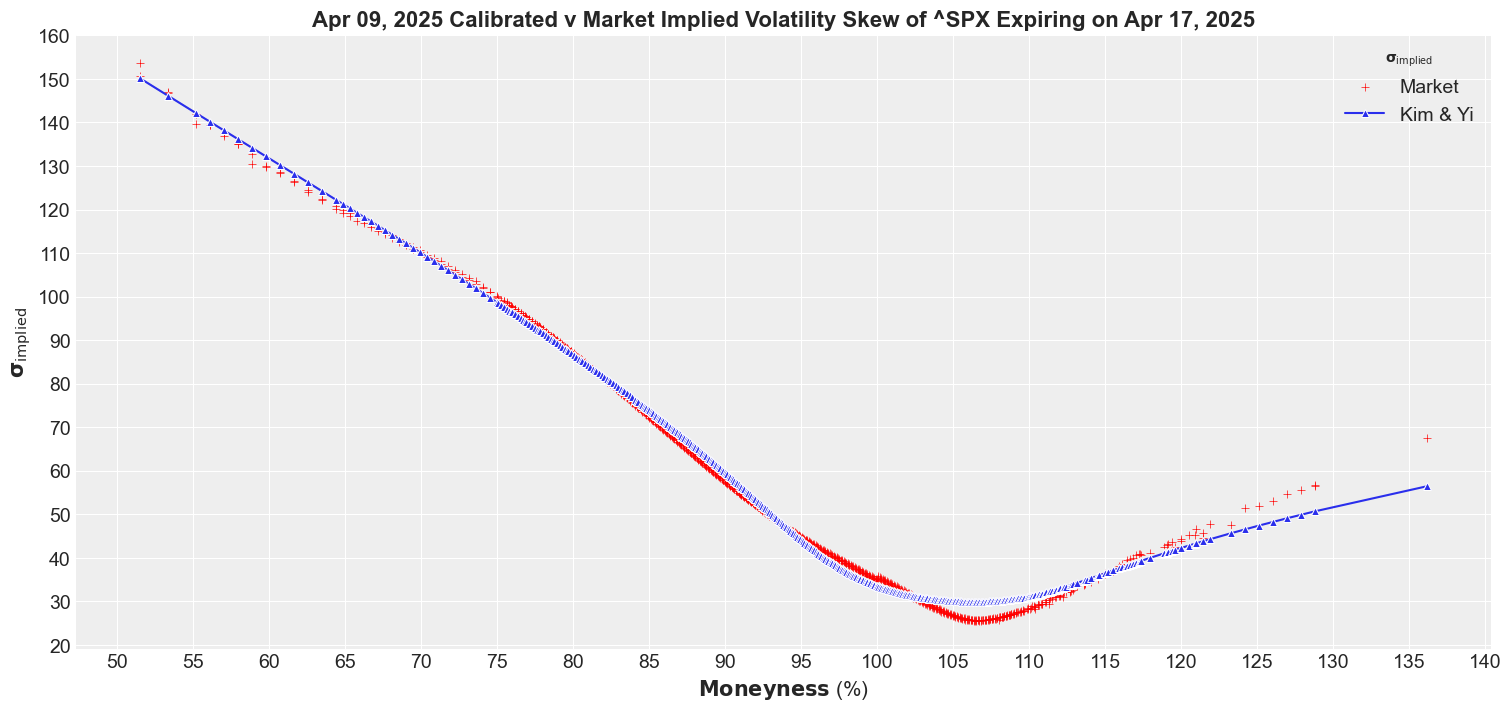

In [68]:
fig, ax = plt.subplots(figsize=(15, 7))

sns.scatterplot(data=tmp_df, x='dMONEYNESS', y='dMKT_IMP_VOL', label='Market', ax=ax, color='red', marker='+')
sns.lineplot(data=tmp_df,  x='dMONEYNESS', y='dMOD_IMP_VOL_KY', label='Kim & Yi', ax=ax, marker='^')
# sns.lineplot(data=tmp_df,  x='dMONEYNESS', y='dMOD_IMP_VOL_H', label='Heston', ax=ax, marker='v')

ax.set(xlabel=rf'$\bf Moneyness$ (%)', ylabel=r'$\bf \sigma_{\text{implied}}$')
ax.legend(title=r'$\bf \sigma_{\text{implied}}$')
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(10))
ax.set_title(
    f'{pd.to_datetime(valuation_date, format="%Y%m%d").strftime("%b %d, %Y")} Calibrated v Market Implied Volatility Skew of {systematic_name} ' +
    f'Expiring on {pd.to_datetime(expiry_date, format="%Y%m%d").strftime("%b %d, %Y")}', weight='bold'
)
plt.savefig(f"SPX_VOL_SKEW_{valuation_date}.pdf", dpi=300)
plt.show();

In [52]:
valuation_date = '20250409'
name = UND_TICKERS_DICT['idiosyncratic'][0]
T = EXPIRY_MAP[pd.to_datetime(valuation_date).weekday()]
if (pd.to_datetime(valuation_date) >= pd.to_datetime('20250407')) and (pd.to_datetime(valuation_date) < pd.to_datetime('20250414')):
    T = T - 1
mask  = (mkt_vol_df.underlying_symbol==name)
mask &= (mkt_vol_df.quote_date==valuation_date) & (mkt_vol_df.iEXPIRY==T) & (mkt_vol_df.dMONEYNESS >= 50.) & (mkt_vol_df.dMONEYNESS <= 150.)
tmp_df = mkt_vol_df.loc[mask].sort_values('dMONEYNESS')
tmp_df.dMKT_IMP_VOL *= 100.
expiry_date = tmp_df.expiration.iloc[0]

sigma, pprob, lamb, eta1, eta2 = calib_rslts_kimyi2025[f"{systematic_name}-{valuation_date}"].x

vol_fitter = KimYiSkewCalibrationIdiosyncratic(
    sigma=np.array(sigma),
    pprob=np.array(pprob),
    lamb=np.array(lamb),
    eta1=np.array(eta1),
    eta2=np.array(eta2),
    mkt_imp_vol=tmp_df.dMKT_IMP_VOL.to_numpy(),
    und_price=tmp_df.dUND_PRICE.to_numpy(),
    und_strike=tmp_df.dUND_STRIKE.to_numpy(),
    risk_free_rate=tmp_df.dRISK_FREE_RATE.to_numpy(),
    dividend_yield=tmp_df.dDIVIDEND_YIELD.to_numpy(),
    time_to_expiry=tmp_df.dEXPIRY.to_numpy(),
    is_call_option=tmp_df.bIS_CALL_OPTION.to_numpy(),
    option_weights=tmp_df.dVEGA.to_numpy() / tmp_df.dVEGA.sum()
)

tmp_df['dMOD_IMP_VOL_KY'] = vol_fitter.model_vol(x=calib_rslts_kimyi2025[f"{name}-{valuation_date}"].x) * 100.

vol_fitter = HestonSkewCalibration(
    mkt_imp_vol=tmp_df.dMKT_IMP_VOL.to_numpy() / 100.,
    und_price=tmp_df.dUND_PRICE.to_numpy(),
    und_strike=tmp_df.dUND_STRIKE.to_numpy(),
    risk_free_rate=tmp_df.dRISK_FREE_RATE.to_numpy(),
    dividend_yield=tmp_df.dDIVIDEND_YIELD.to_numpy(),
    time_to_expiry=tmp_df.dEXPIRY.to_numpy(),
    is_call_option=tmp_df.bIS_CALL_OPTION.to_numpy(),
    option_weights=tmp_df.dVEGA.to_numpy() / tmp_df.dVEGA.sum()
)

tmp_df['dMOD_IMP_VOL_H'] = vol_fitter.model_vol(x=calib_rslts_heston1993[f"{name}-{valuation_date}"].x) * 100.

/Users/josephyi/anaconda3/envs/liquidity/lib/python3.10/site-packages/scipy/integrate/_quadpack_py.py:611: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagse(func,a,b,args,full_output,epsabs,epsrel,limit)


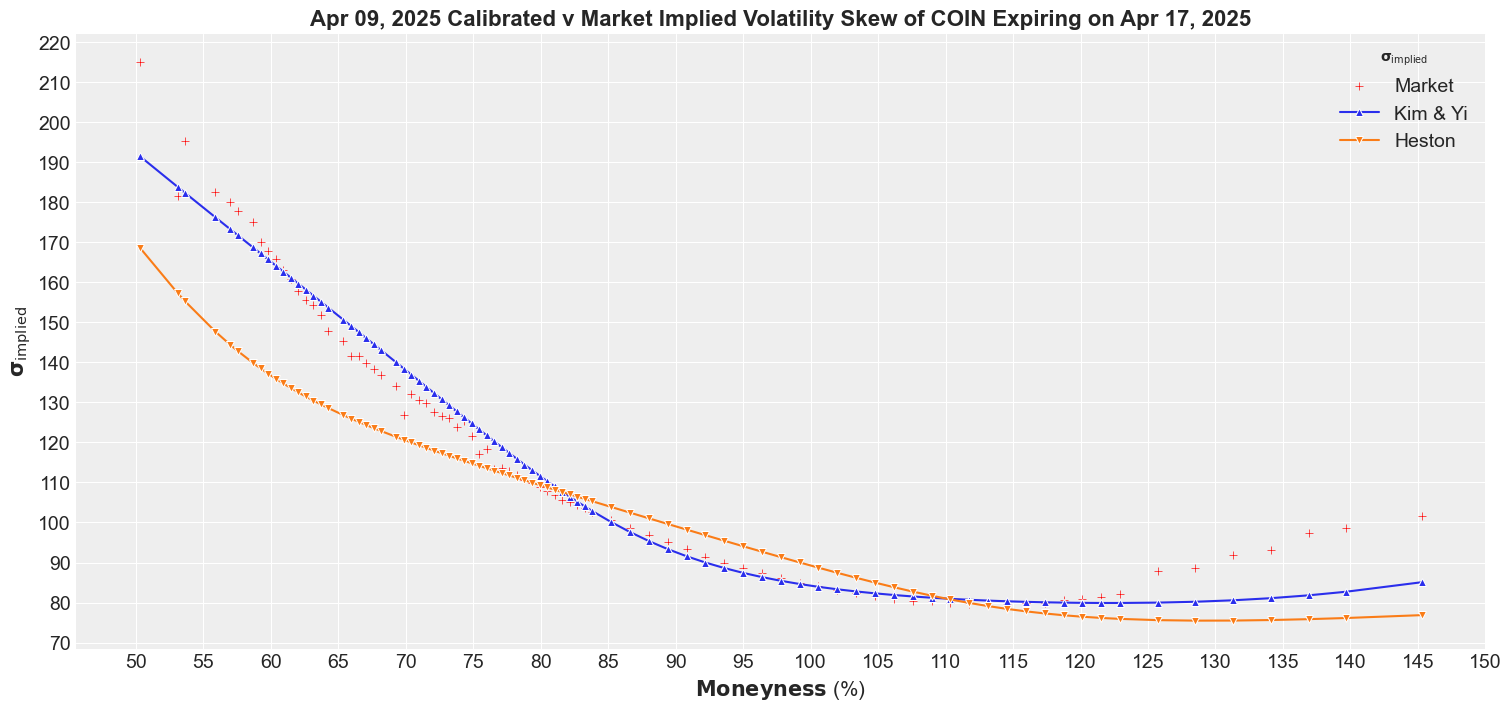

In [53]:
fig, ax = plt.subplots(figsize=(15, 7))

sns.scatterplot(data=tmp_df, x='dMONEYNESS', y='dMKT_IMP_VOL', label='Market', ax=ax, color='red', marker='+')
sns.lineplot(data=tmp_df,  x='dMONEYNESS', y='dMOD_IMP_VOL_KY', label='Kim & Yi', ax=ax, marker='^')
sns.lineplot(data=tmp_df,  x='dMONEYNESS', y='dMOD_IMP_VOL_H', label='Heston', ax=ax, marker='v')

ax.set(xlabel=rf'$\bf Moneyness$ (%)', ylabel=r'$\bf \sigma_{\text{implied}}$')
ax.legend(title=r'$\bf \sigma_{\text{implied}}$')
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(10))
ax.set_title(
    f'{pd.to_datetime(valuation_date, format="%Y%m%d").strftime("%b %d, %Y")} Calibrated v Market Implied Volatility Skew of {UND_TICKERS_DICT["idiosyncratic"][0]} ' +
    f'Expiring on {pd.to_datetime(expiry_date, format="%Y%m%d").strftime("%b %d, %Y")}', weight='bold'
)
plt.savefig(f"COIN_VOL_SKEW_{valuation_date}.pdf", dpi=300)
plt.show();